In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wntr
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.simulation import Simulation
from pipedream_solver.nutils import interpolate_sample
import pipedream_utility as pdu
from pipedream_utility import *
import pipedream_simulation_validation as pd_sim
from pipedream_simulation_validation import run_pipedream_simulation
import viswaternet as vis
import math
import time
import os
#Don't show future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

dt = 600
t_run = 24
# import INP file
inp = 'C-Town.inp'
# run hydraulic simulation using pipedream
t1 = time.time()
H_df, Q_df, Q_o, Q_pump, Q_prv, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult = run_pipedream_simulation(inp, t_run = t_run, dt = dt, banded = False, use_tank_init_cond=False)
t2 = time.time()

print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

0 0.0
0 600.0
0 1200.0
0 1800.0
0 2400.0
0 3000.0
1 3600.0
1 4200.0
1 4800.0
1 5400.0
1 6000.0
1 6600.0
2 7200.0
2 7800.0
2 8400.0
2 9000.0
2 9600.0
2 10200.0
3 10800.0
3 11400.0
3 12000.0
3 12600.0
3 13200.0
3 13800.0
4 14400.0
4 15000.0
4 15600.0
4 16200.0
4 16800.0
4 17400.0
5 18000.0
5 18600.0
5 19200.0
5 19800.0
5 20400.0
5 21000.0
6 21600.0
6 22200.0
6 22800.0
6 23400.0
6 24000.0
6 24600.0
7 25200.0
7 25800.0
7 26400.0
7 27000.0
7 27600.0
7 28200.0


C:\Users\yh24847\OneDrive - The University of Texas at Austin\PhD research\Paper 1 (EKF ctown uncertainty)\code\CorrEKF-State-Estimation-WDS\pipedream_solver\nsuperlink.py:1293: LinAlgWarning: Ill-conditioned matrix (rcond=3.36732e-18): result may not be accurate.
  H_j_next = scipy.linalg.solve(l, r)


8 28800.0
8 29400.0
8 30000.0
8 30600.0
8 31200.0
8 31800.0
9 32400.0
9 33000.0
9 33600.0
9 34200.0
9 34800.0
9 35400.0
10 36000.0
10 36600.0
10 37200.0
10 37800.0
10 38400.0
10 39000.0
11 39600.0
11 40200.0
11 40800.0
11 41400.0
11 42000.0
11 42600.0
12 43200.0
12 43800.0
12 44400.0
12 45000.0
12 45600.0
12 46200.0
13 46800.0
13 47400.0
13 48000.0
13 48600.0
13 49200.0
13 49800.0
14 50400.0
14 51000.0
14 51600.0
14 52200.0
14 52800.0
14 53400.0
15 54000.0
15 54600.0
15 55200.0
15 55800.0
15 56400.0
15 57000.0
16 57600.0
16 58200.0
16 58800.0
16 59400.0
16 60000.0
16 60600.0
17 61200.0
17 61800.0
17 62400.0
17 63000.0
17 63600.0
17 64200.0
18 64800.0
18 65400.0
18 66000.0
18 66600.0
18 67200.0
18 67800.0
19 68400.0
19 69000.0
19 69600.0
19 70200.0
19 70800.0
19 71400.0
20 72000.0
20 72600.0
20 73200.0
20 73800.0
20 74400.0
20 75000.0
21 75600.0
21 76200.0
21 76800.0
21 77400.0
21 78000.0
21 78600.0
22 79200.0
22 79800.0
22 80400.0
22 81000.0
22 81600.0
22 82200.0
23 82800.0
23 83400.0


In [2]:
# run hydraulic simulation using WNTR
wn = wntr.network.WaterNetworkModel(inp)
wn.options.time.report_timestep=dt    
wn.options.time.duration=t_run*3600
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()
# store WNTR results for time series plotting
wntr_heads=results.node['head'].iloc[:-1,:]
wntr_flows=results.link['flowrate'].iloc[:-1,:]

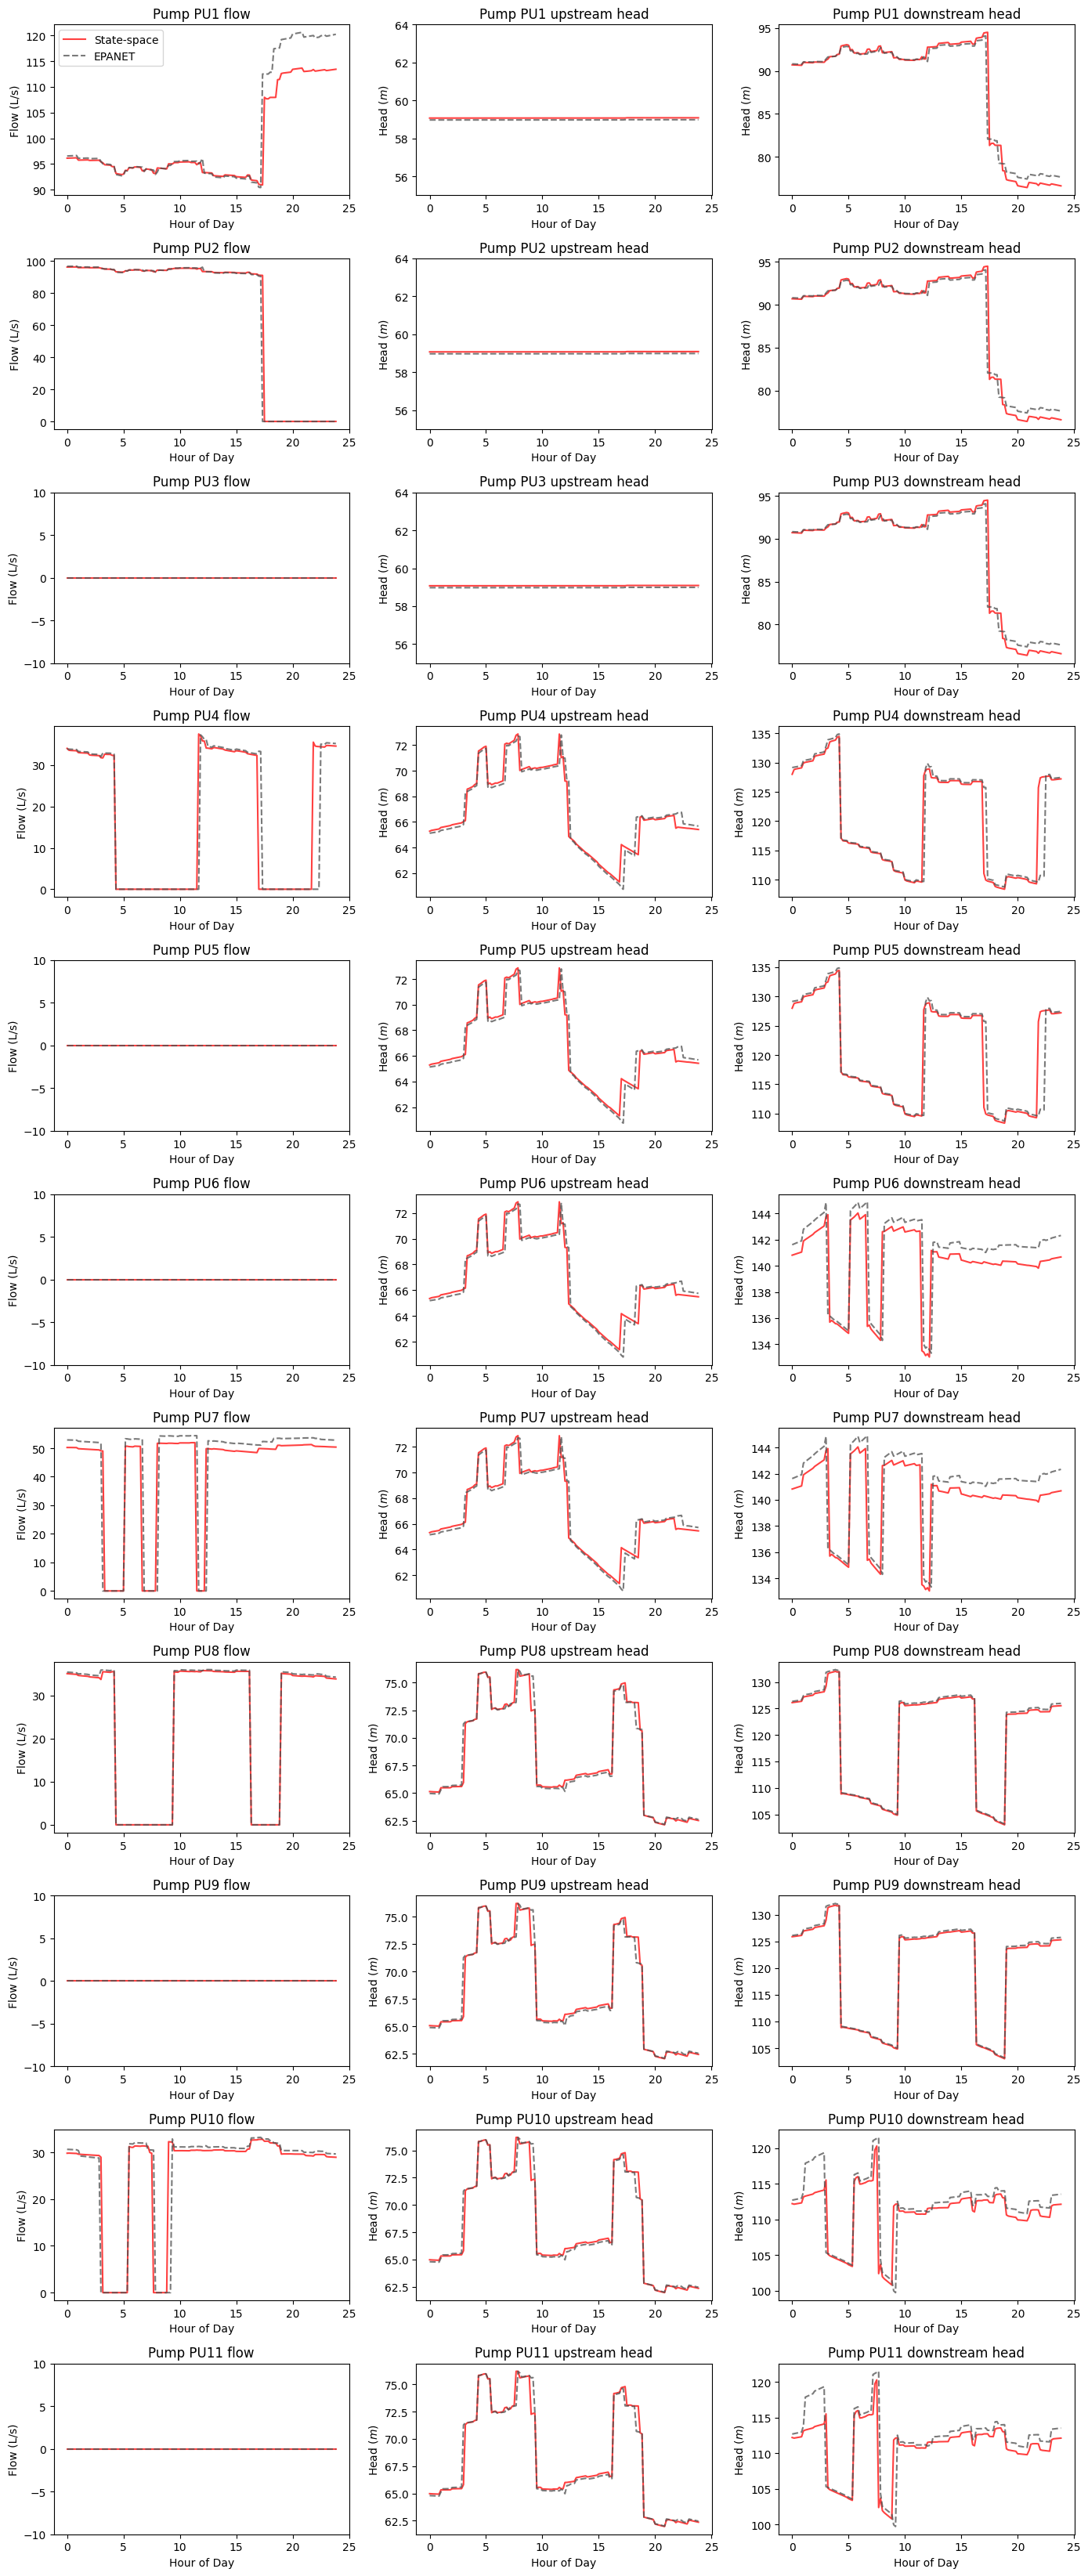

In [3]:
#%% comparison at all the pumps
# plot pipedream and wntr pump flows and upstream + downstream node heads
n_superlinks = wn.num_pumps
n_cols = 3
n_rows = wn.num_pumps
pump_names = wn.pump_name_list
if wn.num_pumps > 0:
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 0.75 * 12 * n_rows / n_cols))
    for i in range(wn.num_pumps):
        pump = wn.get_link(wn.pump_name_list[i])
        ax.flat[3*i].plot(Q_pump.index/3600,Q_pump[pump_names[i]][:]*1000, c='r', alpha=0.75, label = 'State-space')
        ax.flat[3*i].plot(wntr_flows.index/3600,wntr_flows[wn.pump_name_list[i]]*1000, c='0.3', linestyle = '--', alpha=0.75, label = 'EPANET')
        ax.flat[3*i].set_ylabel('Flow (L/s)')
        ax.flat[3*i].set_xlabel('Hour of Day')
        ax.flat[3*i].set_title(f'Pump {wn.pump_name_list[i]} flow')
          
            
        ax.flat[3*i+1].plot(H_df.index/3600,H_df[pump.start_node_name], c='r', alpha=0.75, label = 'State-space')
        ax.flat[3*i+1].plot(wntr_heads.index/3600,wntr_heads[pump.start_node_name], c='0.3', linestyle = '--', alpha=0.75, label = 'EPANET')
        ax.flat[3*i+1].set_title(f'Pump {wn.pump_name_list[i]} upstream head')
        ax.flat[3*i+1].set_ylabel('Head ($m$)')
        ax.flat[3*i+1].set_xlabel('Hour of Day')

        ax.flat[3*i+2].plot(H_df.index/3600,H_df[pump.end_node_name], c='r', alpha=0.75, label = 'State-space')
        ax.flat[3*i+2].plot(wntr_heads.index/3600,wntr_heads[pump.end_node_name], c='0.3', linestyle = '--', alpha=0.75, label = 'EPANET')
        ax.flat[3*i+2].set_title(f'Pump {wn.pump_name_list[i]} downstream head')
        ax.flat[3*i+2].set_ylabel('Head ($m$)')
        ax.flat[3*i+2].set_xlabel('Hour of Day')

       
    ax.flat[0].legend()
    for idx in [1, 4, 7]:
        ax.flat[idx].set_ylim(55, 64)
    plt.tight_layout()
    for idx in [6, 12, 15, 24, 30]:
        ax.flat[idx].set_ylim(-10, 10)
    plt.tight_layout()

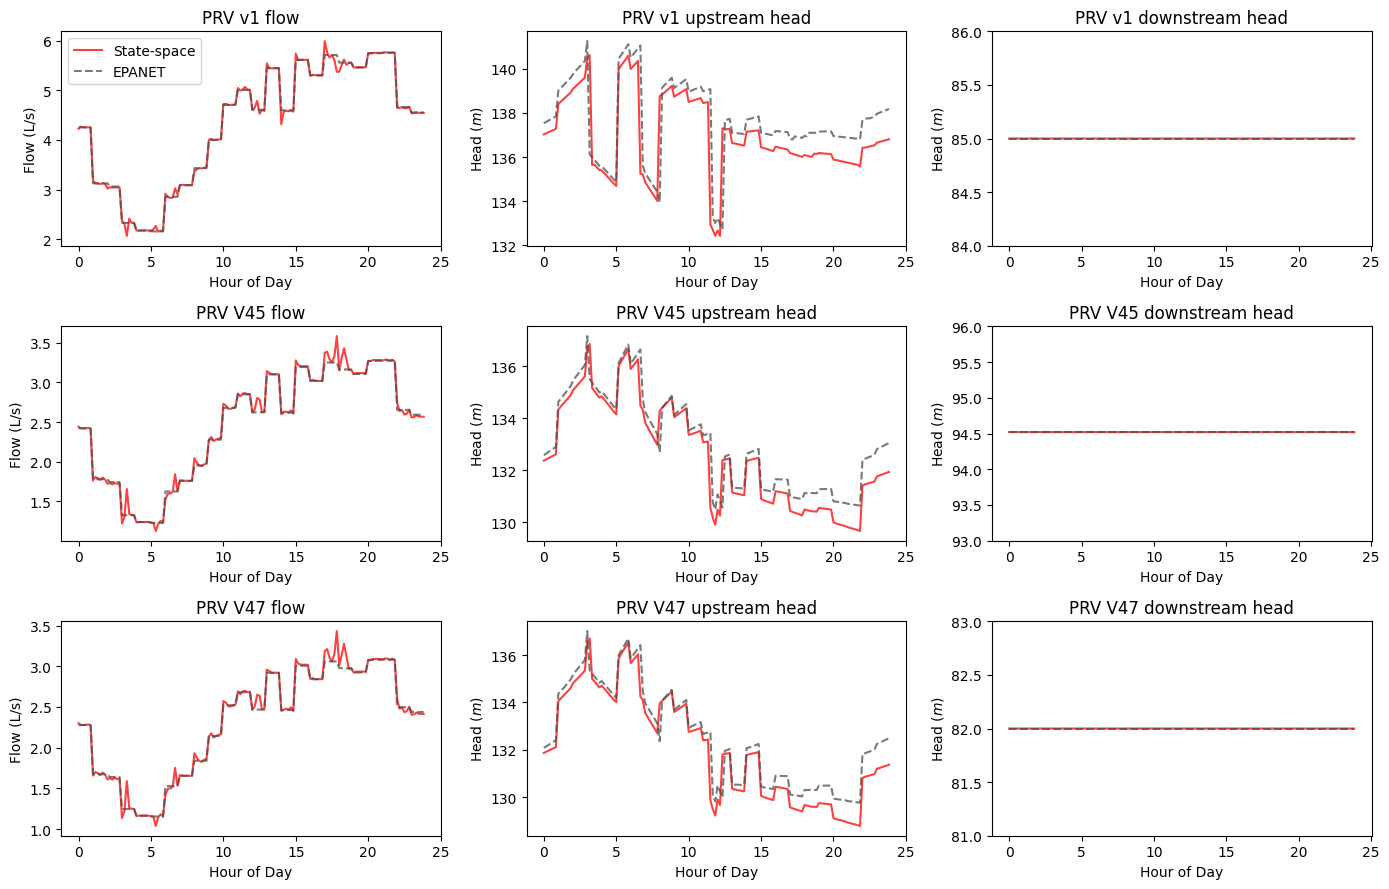

In [4]:
#%%
# plot pipedream and wntr PRV flows and upstream + downstream node heads
n_superlinks = wn.num_valves
n_cols = 3
n_rows =wn.num_valves  
valve_names = wn.valve_name_list
if wn.num_valves > 0:
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 0.75 * 12 * n_rows / n_cols))
    for i in range(wn.num_valves):
        valve = wn.get_link(wn.valve_name_list[i])
        ax.flat[3*i].plot(wntr_flows.index/3600,Q_prv[valve_names[i]][:]*1000, c='r', alpha=0.75, label = 'State-space')
        ax.flat[3*i].plot(wntr_flows.index/3600,wntr_flows[wn.valve_name_list[i]]*1000, c='0.3', linestyle = '--', alpha=0.75, label = 'EPANET')
        ax.flat[3*i].set_ylabel('Flow (L/s)')
        ax.flat[3*i].set_xlabel('Hour of Day')
        ax.flat[3*i].set_title(f'{wn.get_link(wn.valve_name_list[i]).valve_type} {wn.valve_name_list[i]} flow')

        ax.flat[3*i+1].plot(H_df.index/3600,H_df[valve.start_node_name], c='r', alpha=0.75, label = 'State-space')
        ax.flat[3*i+1].plot(wntr_heads.index/3600,wntr_heads[valve.start_node_name], c='0.3', linestyle = '--', alpha=0.75, label = 'EPANET')
        ax.flat[3*i+1].set_title(f'{wn.get_link(wn.valve_name_list[i]).valve_type} {wn.valve_name_list[i]} upstream head')
        #ax.flat[3*i+1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.flat[3*i+1].set_ylabel('Head ($m$)')
        ax.flat[3*i+1].set_xlabel('Hour of Day')

        ax.flat[3*i+2].plot(H_df.index/3600,H_df[valve.end_node_name], c='r', alpha=0.75, label = 'State-space')
        ax.flat[3*i+2].plot(wntr_heads.index/3600,wntr_heads[valve.end_node_name], c='0.3', linestyle = '--', alpha=0.75, label = 'EPANET')
        ax.flat[3*i+2].set_title(f'{wn.get_link(wn.valve_name_list[i]).valve_type} {wn.valve_name_list[i]} downstream head')
        #ax.flat[3*i+2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.flat[3*i+2].set_ylabel('Head ($m$)')
        ax.flat[3*i+2].set_xlabel('Hour of Day')
        ax.flat[3*i+2].set_ylim(math.floor(wntr_heads[valve.end_node_name][0])-1, math.ceil(wntr_heads[valve.end_node_name][0])+1)
    ax.flat[0].legend()
    plt.tight_layout()

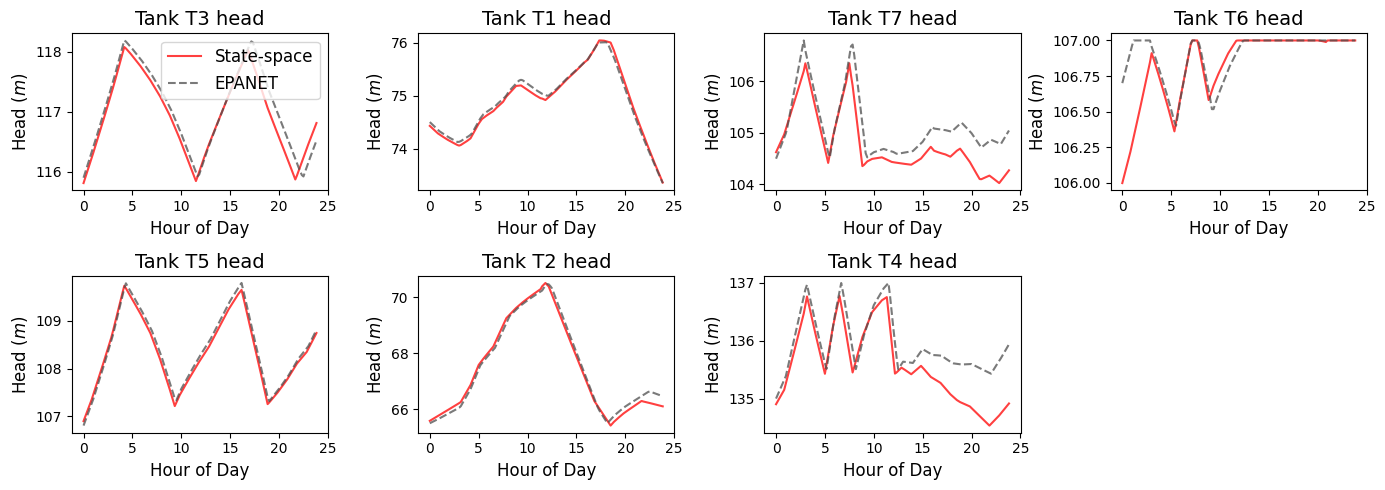

In [5]:
#%%
#plot figures for tanks
start_ind_wn = 0
n_tanks = wn.num_tanks
n_cols = 4
n_rows = 2
tank_name_list = wn.tank_name_list
fake_node_list = ['iT3', 'iT1', 'iT7', 'iT6', 'iT5', 'iT2', 'iT4']

fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 10 * n_rows / n_cols))

for i in range(n_tanks):
    ax.flat[i].plot(H_df.index[start_ind_wn:] / 3600, H_df[tank_name_list[i]][start_ind_wn:], 
                    c='r', alpha=0.75, label='State-space')
    ax.flat[i].plot(wntr_heads.index / 3600, wntr_heads[wn.tank_name_list[i]], 
                    c='0.3', linestyle='--', alpha=0.75, label='EPANET')
    ax.flat[i].set_ylabel('Head ($m$)', fontsize=12)
    ax.flat[i].set_xlabel('Hour of Day', fontsize=12)
    ax.flat[i].set_title(f'Tank {wn.tank_name_list[i]} head', fontsize=14)

ax.flat[0].legend(fontsize=12)

for j in range(n_tanks, n_rows * n_cols):
    fig.delaxes(ax.flat[j])
plt.tight_layout()

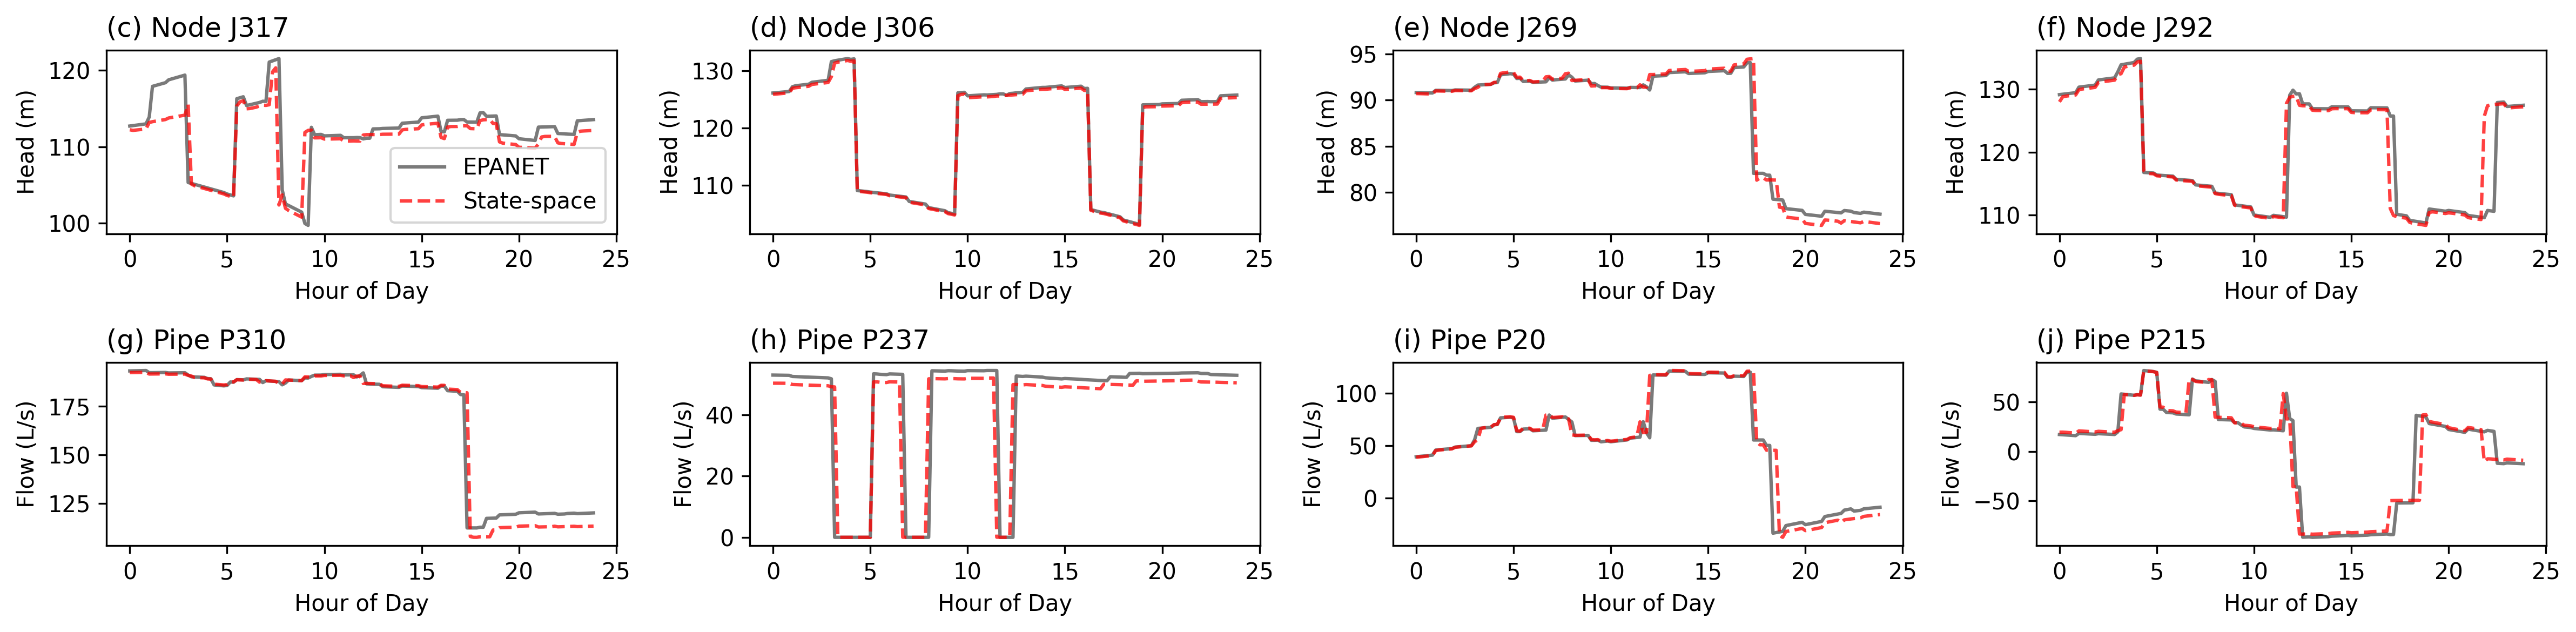

In [7]:
#%% for some other nodes
import string
panel_labels = list(string.ascii_lowercase[2:10])  # (c)–(j)
n_cols = 4
n_rows = 2
start_ind_wn = 0
junction_names= ['J317', 'J306', 'J269', 'J292']
link_names = ['P310', 'P237', 'P20', 'P215']
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4), dpi=300)
for i in range(n_rows * n_cols):
    ax_i = ax.flat[i]

    if i < len(junction_names):
        ax_i.plot(
            wntr_heads.index[start_ind_wn:] / 3600,
            wntr_heads[junction_names[i]][start_ind_wn:],
            c='0.3', alpha=0.75, label='EPANET'
        )
        ax_i.plot(
            H_df.index[start_ind_wn:] / 3600,
            H_df[junction_names[i]][start_ind_wn:],
            c='red', linestyle='--', alpha=0.75, label='State-space'
        )
        ax_i.set_title(f'({panel_labels[i]}) Node {junction_names[i]}', loc='left')
        ax_i.set_ylabel('Head (m)')
        ax_i.set_xlabel('Hour of Day')

    else:
        ax_i.plot(
            wntr_flows.index[start_ind_wn:] / 3600,
            wntr_flows[link_names[i-4]][start_ind_wn:] * 1000,
            c='0.3', alpha=0.75, label='EPANET'
        )
        ax_i.plot(
            Q_df.index[start_ind_wn:] / 3600,
            Q_df[link_names[i-4]][start_ind_wn:] * 1000,
            c='red', linestyle='--', alpha=0.75, label='State-space'
        )
        ax_i.set_title(f'({panel_labels[i]}) Pipe {link_names[i-4]}', loc='left')
        ax_i.set_ylabel('Flow (L/s)')
        ax_i.set_xlabel('Hour of Day')
        
ax.flat[0].legend()
plt.tight_layout()

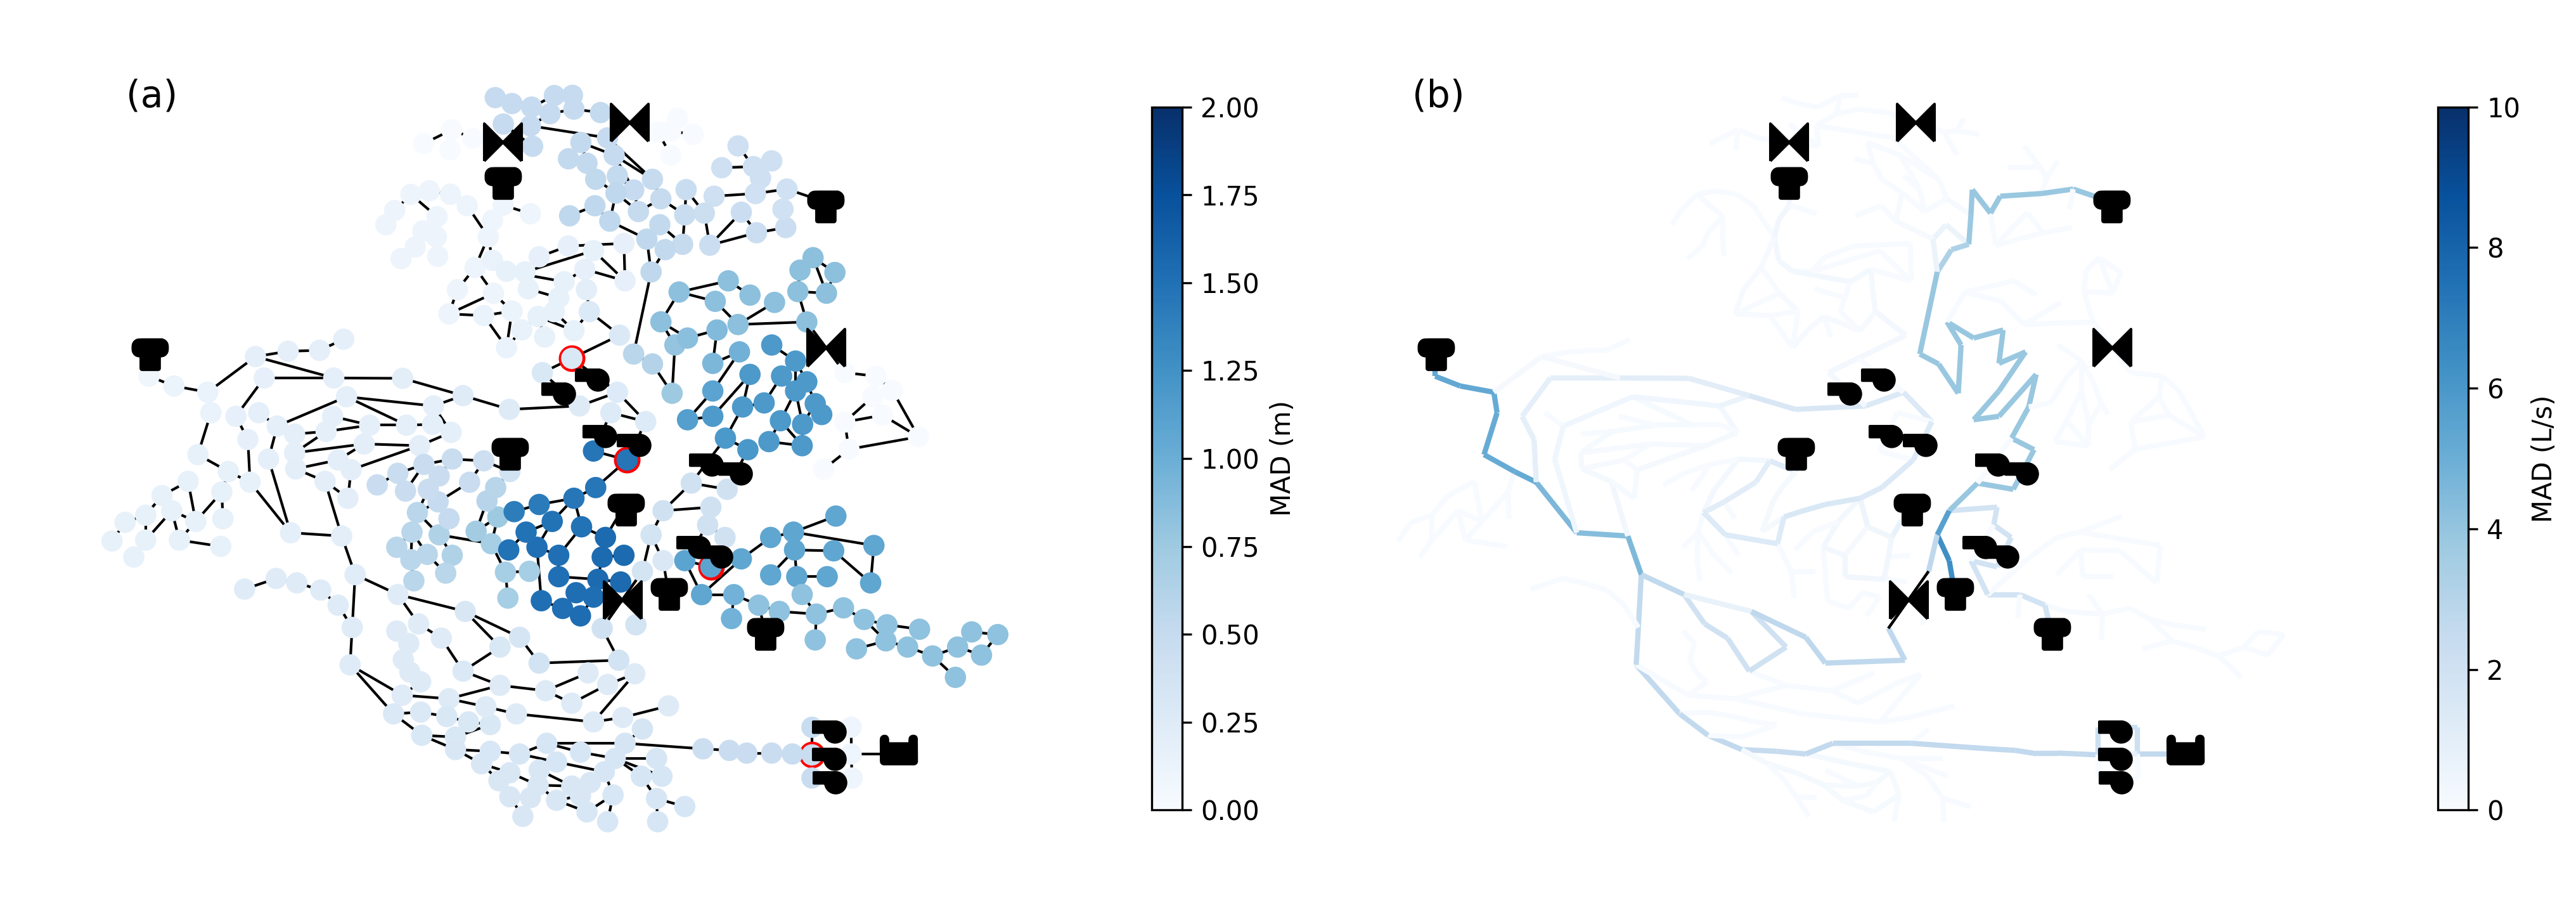

In [8]:
# --- get the names for all the links ---
superlinks = model.superlinks['name'].values
prvs       = model.prvs['name'].values
pumps      = model.pumps['name'].values
# --- calculate the error ---
flow_err_super = (np.abs(Q_df - wntr_flows).mean(axis=0).loc[superlinks]) * 1000
flow_err_prv   = (np.abs(Q_prv - wntr_flows).mean(axis=0).loc[prvs])       * 1000
flow_err_pump  = (np.abs(Q_pump- wntr_flows).mean(axis=0).loc[pumps])      * 1000

# --- merge ---
link_names = np.concatenate([superlinks, prvs, pumps])
flow_err = pd.concat([flow_err_super, flow_err_prv, flow_err_pump])

#%%
junction_names=superjunctions['name'].iloc[:-7].values.tolist() # removing fake node from the list
vis_model = vis.VisWNModel('CTOWN_map.inp')
head_max_limit = 2
head_err = np.abs(H_df - wntr_heads).mean(axis=0).loc[junction_names]
#link_names = model.superlinks['name'].iloc[:].values
flow_max_limit = 10
#flow_err = np.abs(Q_df - wntr_flows).mean(axis=0).loc[link_names] * 1000 # transfer the unit to lps
cmap = 'Blues'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = 2, draw_color_bar = True,  
                                   node_size = node_size, tank_color='k', draw_base_legend=False, color_bar_width = 0.01)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False) 
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=14, fontweight="regular")
vis_model.draw_nodes(ax=ax[0],
                 node_list=['J317', 'J306', 'J269', 'J292'],  # names of nodes to be highlighted
                 # customize highlighted nodes
                 node_color=None, node_size=200, node_border_width=3, node_border_color='r',
                 label='Pressure sensors')
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node', 
                                   custom_data_values = [junction_names, head_err], data_type = 'continuous', 
                                    vmin = 0, vmax=head_max_limit, style = style, color_bar_title ='MAD (m)')
ax[1].set_frame_on(False) 
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=14, fontweight="regular")
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link', 
                           custom_data_values = [link_names, flow_err], data_type = 'continuous', 
                           vmin = 0, vmax = flow_max_limit, style = style, color_bar_title ='MAD (L/s)')